In [3]:
import os
import zipfile
import random
import shutil
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision import transforms

from sklearn.metrics import confusion_matrix, classification_report

In [4]:
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
Device: cuda


In [5]:
#
repo_url="https://github.com/maimunarahma/ai-ml/tree/main/rps-cnn-pytorch"
PROJECT_DIR = "/content/rps-cnn-pytorch"

CUSTOM_DIR = os.path.join(
    PROJECT_DIR,
    "dataset"
)

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "model"
)

os.makedirs(MODEL_DIR, exist_ok=True)

print("Project:", PROJECT_DIR)
print("Custom images:", CUSTOM_DIR)
print("Model:", MODEL_DIR)

Project: /content/rps-cnn-pytorch
Custom images: /content/rps-cnn-pytorch/dataset
Model: /content/rps-cnn-pytorch/model


In [6]:
print("Files in dataset folder:")

# Check if the CUSTOM_DIR exists and has content. If not, attempt to download and extract the project.
# This handles the FileNotFoundError by ensuring the directory is present and populated.
if not os.path.exists(CUSTOM_DIR) or not os.listdir(CUSTOM_DIR):
    print(f"Directory '{CUSTOM_DIR}' is empty or does not exist. Attempting to download project.")

    # Define download URL for the entire repository's main branch as a zip
    zip_url = "https://github.com/maimunarahma/ai-ml/archive/main.zip"
    zip_filename = "ai-ml-main.zip"
    extracted_folder_name = "ai-ml-main"
    source_subfolder = os.path.join(extracted_folder_name, "rps-cnn-pytorch")

    # Clean up previous attempts if present
    if os.path.exists(PROJECT_DIR) and not os.listdir(PROJECT_DIR): # if PROJECT_DIR exists but is empty
        shutil.rmtree(PROJECT_DIR)
    if os.path.exists(zip_filename):
        os.remove(zip_filename)
    if os.path.exists(extracted_folder_name):
        shutil.rmtree(extracted_folder_name)

    # Download the zip file
    print(f"Downloading {zip_url}...")
    urllib.request.urlretrieve(zip_url, zip_filename)

    # Extract the zip file
    print(f"Extracting {zip_filename}...")
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall('.')

    # Move the 'rps-cnn-pytorch' subfolder contents to PROJECT_DIR
    if os.path.exists(source_subfolder):
        os.makedirs(PROJECT_DIR, exist_ok=True) # Ensure PROJECT_DIR exists before copying
        print(f"Moving contents from {source_subfolder} to {PROJECT_DIR}...")
        # Use shutil.copytree with dirs_exist_ok=True to merge directories if PROJECT_DIR exists
        shutil.copytree(source_subfolder, PROJECT_DIR, dirs_exist_ok=True)
        print("Project content moved successfully.")
    else:
        print(f"Error: Subfolder '{source_subfolder}' not found in extracted archive. Project may not be set up correctly.")

    # Clean up downloaded zip and extracted temporary folder
    if os.path.exists(zip_filename):
        os.remove(zip_filename)
    if os.path.exists(extracted_folder_name):
        shutil.rmtree(extracted_folder_name)
    print("Cleanup complete.")

# Now, list the files in CUSTOM_DIR if it exists
if os.path.exists(CUSTOM_DIR) and os.path.isdir(CUSTOM_DIR):
    print("Files in dataset folder:")
    for file in sorted(os.listdir(CUSTOM_DIR)):
        print(file)
else:
    print(f"Error: Directory '{CUSTOM_DIR}' still does not exist or is not a directory after attempted fix. Please check your repo_url and directory structure.")

Files in dataset folder:
Directory '/content/rps-cnn-pytorch/dataset' is empty or does not exist. Attempting to download project.
Extracting ai-ml-main.zip...
Moving contents from ai-ml-main/rps-cnn-pytorch to /content/rps-cnn-pytorch...
Project content moved successfully.
Cleanup complete.
Files in dataset folder:
paper1.jpeg
paper2.jpeg
paper3.jpeg
rock1.jpeg
rock2.jpeg
rock3.jpeg
rock4.jpeg
scissor1.jpeg
scissor2.jpeg
scissor3.jpeg


### Visualize Sample Images

Let's visualize a few sample images from the dataset to understand their content.

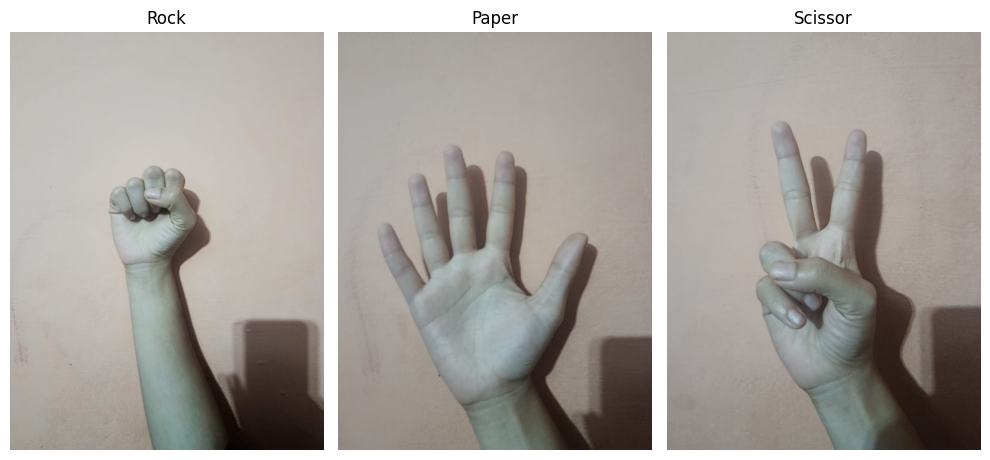

In [7]:
labels = ['rock', 'paper', 'scissor']

plt.figure(figsize=(10, 10))

for i, label in enumerate(labels):
    # Find images belonging to the current label
    # Assuming filenames contain the label (e.g., 'rock1.jpeg')
    label_images = [f for f in os.listdir(CUSTOM_DIR) if label in f.lower()]

    if label_images:
        # Pick a random image for each label
        sample_image_name = random.choice(label_images)
        image_path = os.path.join(CUSTOM_DIR, sample_image_name)

        # Load and display the image
        img = Image.open(image_path)
        plt.subplot(1, len(labels), i + 1) # Create subplot for each label
        plt.imshow(img)
        plt.title(label.capitalize())
        plt.axis('off')
    else:
        print(f"No images found for label: {label}")

plt.tight_layout()
plt.show()

In [8]:
# download rps dataset
DATA_DIR = "/content/rps_data"

os.makedirs(DATA_DIR, exist_ok=True)

TRAIN_URL = (
    "https://storage.googleapis.com/"
    "download.tensorflow.org/data/rps.zip"
)

TEST_URL = (
    "https://storage.googleapis.com/"
    "download.tensorflow.org/data/rps-test-set.zip"
)

TRAIN_ZIP = os.path.join(
    DATA_DIR,
    "rps.zip"
)

TEST_ZIP = os.path.join(
    DATA_DIR,
    "rps-test-set.zip"
)

In [9]:
if not os.path.exists(TRAIN_ZIP):

    print("Downloading training dataset...")

    urllib.request.urlretrieve(
        TRAIN_URL,
        TRAIN_ZIP
    )

if not os.path.exists(TEST_ZIP):

    print("Downloading test dataset...")

    urllib.request.urlretrieve(
        TEST_URL,
        TEST_ZIP
    )

print("Download complete.")

Download complete.


In [10]:
# Extract to DATA_DIR. The zip files contain a top-level folder (e.g., 'rps').
# So, extraction to DATA_DIR will result in DATA_DIR/rps/rock, DATA_DIR/rps/paper, etc.
if not os.path.exists(os.path.join(DATA_DIR, "rps")):
    with zipfile.ZipFile(
        TRAIN_ZIP,
        "r"
    ) as zip_ref:
        zip_ref.extractall(
            DATA_DIR
        )

if not os.path.exists(os.path.join(DATA_DIR, "rps-test-set")):
    with zipfile.ZipFile(
        TEST_ZIP,
        "r"
    ) as zip_ref:
        zip_ref.extractall(
            DATA_DIR
        )

# Define TRAIN_DIR and TEST_DIR to point to the correct subdirectories within the extracted folders.
# The directory investigation showed the classes are directly under DATA_DIR/rps and DATA_DIR/rps-test-set.
TRAIN_DIR = os.path.join(DATA_DIR, "rps")
TEST_DIR = os.path.join(DATA_DIR, "rps-test-set")

print("Extraction complete.")
print(f"TRAIN_DIR set to: {TRAIN_DIR}")
print(f"TEST_DIR set to: {TEST_DIR}")

Extraction complete.
TRAIN_DIR set to: /content/rps_data/rps
TEST_DIR set to: /content/rps_data/rps-test-set


In [11]:
print(os.listdir(TRAIN_DIR))
print(os.listdir(TEST_DIR))

['paper', 'rock', 'scissors']
['paper', 'rock', 'scissors']


In [12]:
print('--- Investigating DATA_DIR contents ---')
print(f"Contents of DATA_DIR ({DATA_DIR}): {os.listdir(DATA_DIR)}")

# Let's check a few levels deeper based on the 'rps' folder found in DATA_DIR
path1 = os.path.join(DATA_DIR, 'rps')
if os.path.exists(path1):
    print(f"Contents of {path1}: {os.listdir(path1)}")

    path2 = os.path.join(path1, 'rps')
    if os.path.exists(path2):
        print(f"Contents of {path2}: {os.listdir(path2)}")

        path3 = os.path.join(path2, 'rps')
        if os.path.exists(path3):
            print(f"Contents of {path3}: {os.listdir(path3)}")

            path4 = os.path.join(path3, 'rps')
            if os.path.exists(path4):
                print(f"Contents of {path4}: {os.listdir(path4)}")

            path5 = os.path.join(path4, 'rps')
            if os.path.exists(path5):
                print(f"Contents of {path5}: {os.listdir(path5)}")

print('--- Investigation complete ---')


--- Investigating DATA_DIR contents ---
Contents of DATA_DIR (/content/rps_data): ['rps-test-set', 'rps.zip', 'rps', 'rps-test-set.zip']
Contents of /content/rps_data/rps: ['paper', 'rock', 'scissors']
--- Investigation complete ---


In [13]:
from torchvision import datasets, transforms

IMG_SIZE = 128

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=transform
)

print("Classes:", train_dataset.classes)
print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))

Classes: ['paper', 'rock', 'scissors']
Training images: 2520
Test images: 372


In [14]:
# train test split
from torch.utils.data import random_split

torch.manual_seed(42)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Training: 2016
Validation: 504
Test: 372


In [15]:
# dataloader
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


In [16]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([64, 3, 128, 128])
Label batch shape: torch.Size([64])


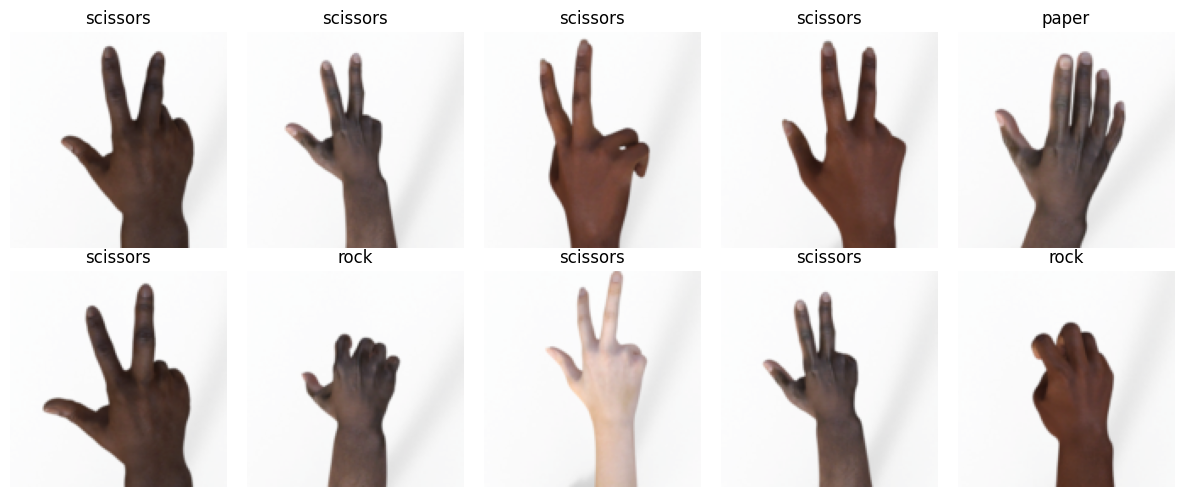

In [17]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(iter(train_loader))

# Helper function to get the base dataset from a potentially nested Subset
def get_base_dataset(dataset):
    current = dataset
    while isinstance(current, torch.utils.data.Subset):
        current = current.dataset
    return current

# Define class_names from the dataset
# Access .dataset to get the original ImageFolder which has .classes
base_train_dataset = get_base_dataset(train_dataset)
class_names = base_train_dataset.classes

fig, axes = plt.subplots(
    2, 5,
    figsize=(12, 5)
)

for i, ax in enumerate(axes.flat):
    # Ensure we don't go out of bounds if there are fewer images than subplots
    if i < len(images):
        image = images[i].permute(1, 2, 0).numpy()

        # Undo normalization for visualization
        image = (
            image * np.array([0.229, 0.224, 0.225])
            + np.array([0.485, 0.456, 0.406])
        )

        image = np.clip(image, 0, 1)

        ax.imshow(image)
        ax.set_title(class_names[labels[i]])
        ax.axis("off")
    else:
        ax.axis("off") # Turn off empty subplots

plt.tight_layout()
plt.show()

In [18]:
## 4. CNN Model Architecture
import torch.nn as nn

class CNN(nn.Module):

    def __init__(self, num_classes=3):
        super(CNN, self).__init__()

        self.features = nn.Sequential(

            # Convolution Block 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Convolution Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Convolution Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 16 * 16,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [19]:
model = CNN(
    num_classes=len(class_names)
)

model = model.to(device)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=3, bias=True)
  )
)


In [20]:
sample_images, sample_labels = next(
    iter(train_loader)
)

sample_images = sample_images.to(device)

output = model(sample_images)

print("Input shape :", sample_images.shape)
print("Output shape:", output.shape)

Input shape : torch.Size([64, 3, 128, 128])
Output shape: torch.Size([64, 3])


In [21]:

# loss function
criterion = nn.CrossEntropyLoss()

In [22]:
# optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [23]:
print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [24]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

    epoch_loss = running_loss / total

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [25]:
# validation function
def evaluate(
    model,
    dataloader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            total += labels.size(0)

            correct += (
                predictions == labels
            ).sum().item()

    epoch_loss = running_loss / total

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [26]:
NUM_EPOCHS = 15

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [27]:
MODEL_PATH = os.path.join(
    MODEL_DIR,
    "210121.pth"
)

print(MODEL_PATH)

/content/rps-cnn-pytorch/model/210121.pth


In [28]:
best_val_accuracy = 0.0

for epoch in range(NUM_EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy*100:.2f}% "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy*100:.2f}%"
    )

    # Save best model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )

print("\nTraining complete!")
print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy*100:.2f}%"
)
print(
    "Model saved at:",
    MODEL_PATH
)

Epoch [1/15] | Train Loss: 0.7862 | Train Acc: 68.35% | Val Loss: 0.1368 | Val Acc: 95.83%
Epoch [2/15] | Train Loss: 0.0741 | Train Acc: 98.36% | Val Loss: 0.0211 | Val Acc: 99.60%
Epoch [3/15] | Train Loss: 0.0078 | Train Acc: 99.90% | Val Loss: 0.0011 | Val Acc: 100.00%
Epoch [4/15] | Train Loss: 0.0014 | Train Acc: 100.00% | Val Loss: 0.0005 | Val Acc: 100.00%
Epoch [5/15] | Train Loss: 0.0012 | Train Acc: 100.00% | Val Loss: 0.0004 | Val Acc: 100.00%
Epoch [6/15] | Train Loss: 0.0009 | Train Acc: 100.00% | Val Loss: 0.0001 | Val Acc: 100.00%
Epoch [7/15] | Train Loss: 0.0006 | Train Acc: 100.00% | Val Loss: 0.0001 | Val Acc: 100.00%
Epoch [8/15] | Train Loss: 0.0002 | Train Acc: 100.00% | Val Loss: 0.0001 | Val Acc: 100.00%
Epoch [9/15] | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0000 | Val Acc: 100.00%
Epoch [10/15] | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0000 | Val Acc: 100.00%
Epoch [11/15] | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0000

In [29]:
torch.save(
    model.state_dict(),
    MODEL_PATH
)

In [30]:
test_loss, test_accuracy = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.9697
Test Accuracy: 77.69%


In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Class names:", class_names)
print("\nConfusion Matrix:")
print(cm)

Class names: ['paper', 'rock', 'scissors']

Confusion Matrix:
[[121   0   3]
 [ 19  89  16]
 [ 34  11  79]]


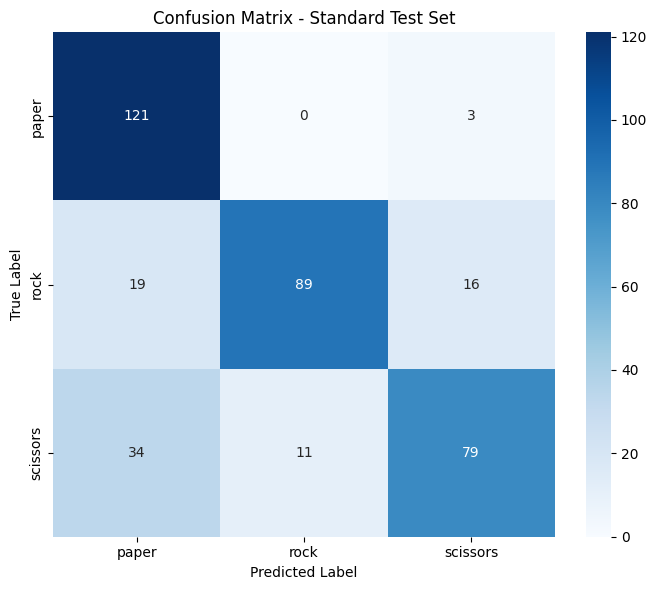

In [32]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Standard Test Set")

plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       paper       0.70      0.98      0.81       124
        rock       0.89      0.72      0.79       124
    scissors       0.81      0.64      0.71       124

    accuracy                           0.78       372
   macro avg       0.80      0.78      0.77       372
weighted avg       0.80      0.78      0.77       372



In [34]:
incorrect_samples = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        for i in range(len(labels)):

            true_label = labels[i].item()
            predicted_label = predictions[i].item()

            if true_label != predicted_label:

                incorrect_samples.append(
                    (
                        images[i].cpu(),
                        true_label,
                        predicted_label
                    )
                )

print(
    "Number of incorrect test images:",
    len(incorrect_samples)
)

Number of incorrect test images: 83


In [35]:
import random

random.seed(42)

if incorrect_samples:
    samples = random.sample(
        incorrect_samples,
        min(len(incorrect_samples), 3)
    )
else:
    print("No incorrect samples to display.")
    samples = [] # Ensure 'samples' is defined even if empty


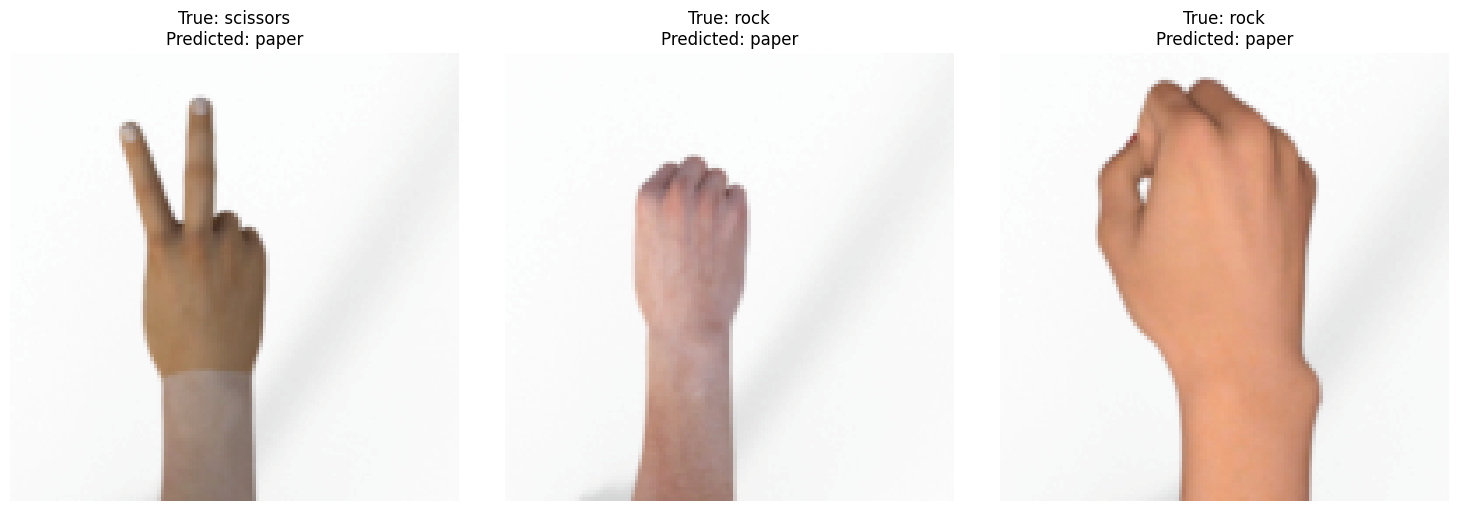

In [36]:
if samples:
    fig, axes = plt.subplots(
        1,
        len(samples),
        figsize=(5 * len(samples), 5)
    )

    # Ensure axes is an array even for a single sample
    if len(samples) == 1:
        axes = [axes]

    for ax, (
        image,
        true_label,
        predicted_label
    ) in zip(axes, samples):

        image = image.permute(
            1, 2, 0
        ).numpy()

        # Undo normalization
        image = (
            image * np.array([0.229, 0.224, 0.225])
            + np.array([0.485, 0.456, 0.406])
        )

        image = np.clip(
            image,
            0,
            1
        )

        ax.imshow(image)

        ax.set_title(
            f"True: {class_names[true_label]}\n"
            f"Predicted: {class_names[predicted_label]}"
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No incorrect samples to display, as the model achieved 100% accuracy.")


In [37]:
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best saved model loaded successfully.")

Best saved model loaded successfully.


In [38]:
def predict_custom_image(image_path):

    # Open image
    image = Image.open(
        image_path
    ).convert("RGB")

    # Same transform used during training
    image_tensor = transform(
        image
    )

    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0)

    # Move to GPU/CPU
    image_tensor = image_tensor.to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(
            image_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, predicted = torch.max(
            probabilities,
            dim=1
        )

    predicted_class = class_names[
        predicted.item()
    ]

    confidence = confidence.item()

    return (
        image,
        predicted_class,
        confidence
    )

In [39]:
image_extensions = (
    ".jpg",
    ".jpeg",
    ".png"
)

custom_images = []

for filename in sorted(
    os.listdir(CUSTOM_DIR)
):

    if filename.lower().endswith(
        image_extensions
    ):

        custom_images.append(
            os.path.join(
                CUSTOM_DIR,
                filename
            )
        )

print(
    "Number of custom images:",
    len(custom_images)
)

for image_path in custom_images:
    print(
        os.path.basename(image_path)
    )

Number of custom images: 10
paper1.jpeg
paper2.jpeg
paper3.jpeg
rock1.jpeg
rock2.jpeg
rock3.jpeg
rock4.jpeg
scissor1.jpeg
scissor2.jpeg
scissor3.jpeg


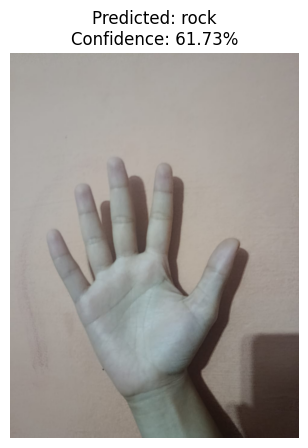

In [40]:
image_path = custom_images[0]

image, prediction, confidence = (
    predict_custom_image(
        image_path
    )
)

plt.figure(figsize=(5, 5))

plt.imshow(image)

plt.title(
    f"Predicted: {prediction}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.axis("off")

plt.show()

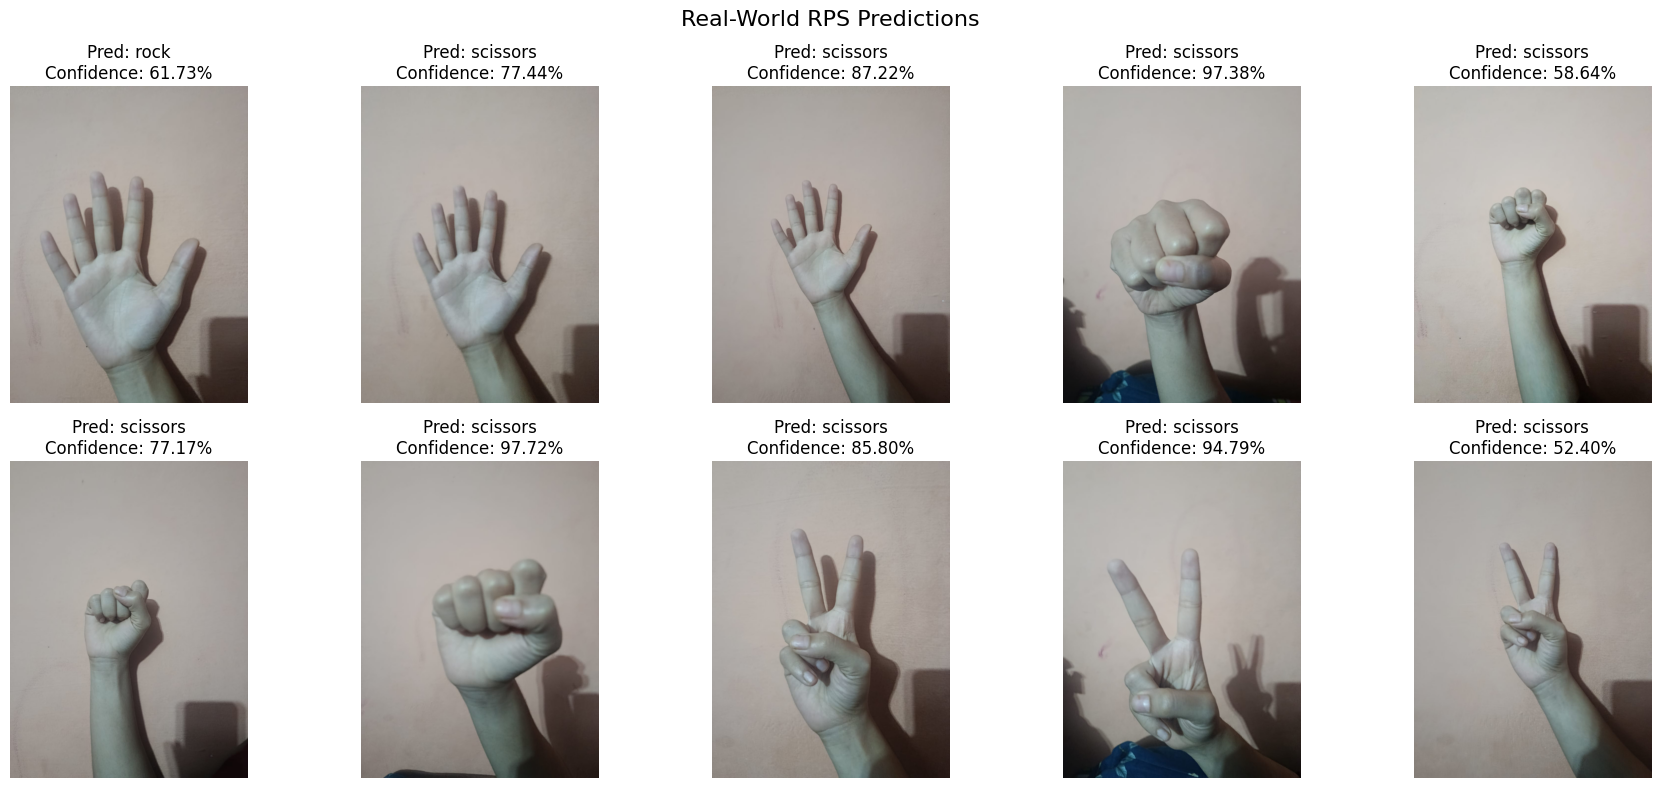

In [41]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 8)
)

for ax, image_path in zip(
    axes.flat,
    custom_images
):

    image, prediction, confidence = (
        predict_custom_image(
            image_path
        )
    )

    ax.imshow(image)

    ax.set_title(
        f"Pred: {prediction}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )

    ax.axis("off")

plt.suptitle(
    "Real-World RPS Predictions",
    fontsize=16
)

plt.tight_layout()

plt.show()

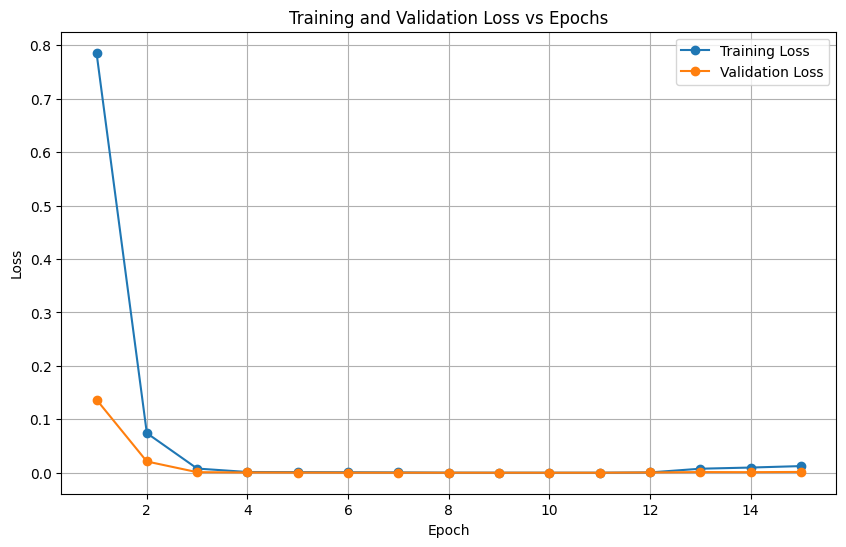

In [42]:
import matplotlib.pyplot as plt

epochs = range(1, 16)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    train_losses,
    marker='o',
    label='Training Loss'
)

plt.plot(
    epochs,
    val_losses,
    marker='o',
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss vs Epochs')
plt.legend()
plt.grid(True)

plt.show()

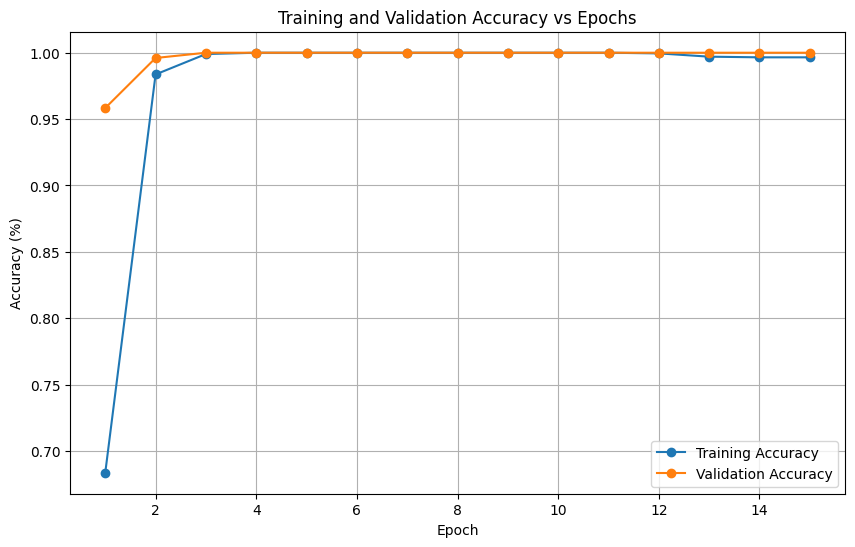

In [43]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    train_accuracies,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    epochs,
    val_accuracies,
    marker='o',
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy vs Epochs')
plt.legend()
plt.grid(True)

plt.show()